In [ ]:
import os
import sys
import plotly.graph_objects as go

import matplotlib.pyplot as plt

In [13]:
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

from src.models.utils import *
import pandas as pd

plants_temperature_path = os.path.join(project_root, "data", "raw", "PlantsTemperature_View_original.csv")
p_temp_df = pd.read_csv(plants_temperature_path, encoding='utf-8')

p_temp_df["HourNo"] = p_temp_df["HourNo"].astype(int)
p_temp_df["Date"] = p_temp_df["Date"].apply(jalali_to_gregorian_fast)
p_temp_df["datetime"] = pd.to_datetime(p_temp_df["Date"]) + pd.to_timedelta(p_temp_df["HourNo"], unit='h')

is_env = p_temp_df["Code"] == "SCADAF"
env_df = p_temp_df[is_env]
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
semi_integrated_df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')
semi_integrated_df['date'] = pd.to_datetime(semi_integrated_df['date'])
semi_integrated_df['datetime'] = semi_integrated_df['date'] + pd.to_timedelta(semi_integrated_df['hour'], unit='h')
semi_integrated_df = semi_integrated_df.rename(columns={"name": "PowerPlantName"})

semi_integrated_df = semi_integrated_df[(semi_integrated_df["is_good_peak"] >= 3)]

df_merged_env = pd.merge(semi_integrated_df, env_df, on=["datetime", "PowerPlantName"], how="inner")
df_merged_env = df_merged_env[['PowerPlantName', 'code', 'date', 'hour', 'temperature', 'Value', 'generation']].dropna()
df_merged_env = df_merged_env.rename(columns={"Value": "env_temperature"})
df_merged_env = df_merged_env.rename(columns={"PowerPlantName": "name"})


In [21]:
real_temps1 = df_merged_env['temperature'].values
real_temps2 = df_merged_env['env_temperature'].values


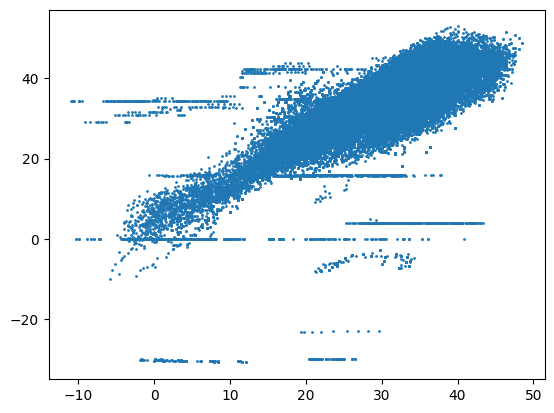

In [22]:
plt.scatter(real_temps1, real_temps2, s=1)
plt.show()

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [24]:
X = real_temps1.reshape(-1, 1)
y = real_temps2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_error = compute_relative_rmse(y_pred_train, y_train)
test_error = compute_relative_rmse(y_pred_test, y_test)

print(f"train error: {train_error:0.2f}, test error: {test_error:0.2f}")


train error: 17.97, test error: 17.76
